# Milestone 1 Pre-processing

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import datetime
import matplotlib.cm as cm

## ATP Matches Single

In [22]:
files = glob.glob('datasets/tennis_atp/atp_matches_*.csv')

df = pd.concat(
    [pd.read_csv(f, parse_dates=['tourney_date'], date_format="%Y%m%d") for f in files],
    ignore_index=True)

df['tourney_date'] = pd.to_datetime(df['tourney_date'], errors='coerce')

df.head()

/var/folders/k2/dk8bt59j05qbxf2_m65bzn380000gn/T/ipykernel_23485/1563983919.py:4: DtypeWarning: Columns (0: draw_size) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(f, parse_dates=['tourney_date'], date_format="%Y%m%d") for f in files],


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,loser2_ioc,loser2_age,winner1_rank,winner1_rank_points,winner2_rank,winner2_rank_points,loser1_rank,loser1_rank_points,loser2_rank,loser2_rank_points
0,2019-M020,Brisbane,Hard,32,A,2018-12-31,300,105453.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-M020,Brisbane,Hard,32,A,2018-12-31,299,106421.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-M020,Brisbane,Hard,32,A,2018-12-31,298,105453.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-M020,Brisbane,Hard,32,A,2018-12-31,297,104542.0,NaN,PR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-M020,Brisbane,Hard,32,A,2018-12-31,296,106421.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
df.columns

Index(['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
       'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry',
       'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age',
       'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand',
       'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round',
       'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon',
       'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt',
       'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced',
       'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points',
       'winner1_id', 'winner2_id', 'loser1_id', 'loser2_id', 'winner1_name',
       'winner1_hand', 'winner1_ht', 'winner1_ioc', 'winner1_age',
       'winner2_name', 'winner2_hand', 'winner2_ht', 'winner2_ioc',
       'winner2_age', 'loser1_name', 'loser1_hand', 'loser1_ht', 'loser1_ioc',
       'loser1

In [35]:
print(df['surface'].unique()[23:])

[33.9137577002 35.8220396988 38.6447638604 ... 38.5681040383 23.4551676934
 27.8795345654]


In [49]:
# Some basic statistics

unique_winners = set(df['winner_id'].unique())
unique_loser = set(df['loser_id'].unique())
unique_players = unique_winners.union(unique_loser)

print('------------ Stats ------------')
print(f"Total number of matches: {df.shape[0]}")
print(f"Total number of players: {len(unique_players)}")
print(f"Date of the first match: {df['tourney_date'].min().strftime('%Y-%m-%d')}")
print(f"Date of the last match: {df['tourney_date'].max().strftime('%Y-%m-%d')}")
print(f"Average duration of a match: {df['minutes'].mean():.2f} min")

------------ Stats ------------
Total number of matches: 968048
Total number of players: 34064
Date of the first match: 1877-07-09
Date of the last match: 2024-12-18
Average duration of a match: 100.27 min


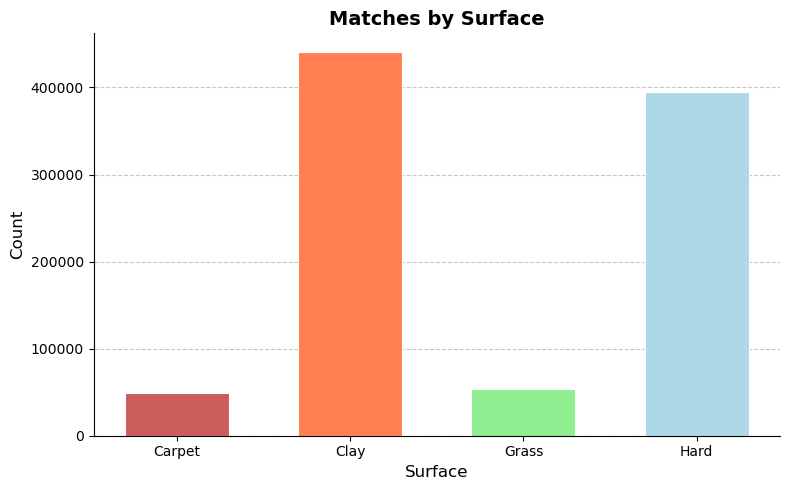

In [46]:
df_surfaces = df.groupby('surface').size().reset_index(name='count')
df_surfaces = df_surfaces[df_surfaces['surface'].isin(['Clay', 'Hard', 'Grass', 'Carpet'])]

fig, ax = plt.subplots(figsize=(8, 5))

colors = {'Clay': 'coral', 'Hard': 'lightblue', 'Grass': 'lightgreen', 'Carpet': 'indianred'}

ax.bar(
    df_surfaces['surface'],
    df_surfaces['count'],
    color=[colors[s] for s in df_surfaces['surface']],
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

ax.set_xlabel('Surface', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Matches by Surface', fontsize=14, fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

/var/folders/k2/dk8bt59j05qbxf2_m65bzn380000gn/T/ipykernel_23485/1338802727.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Accent', len(df_tourney_level))


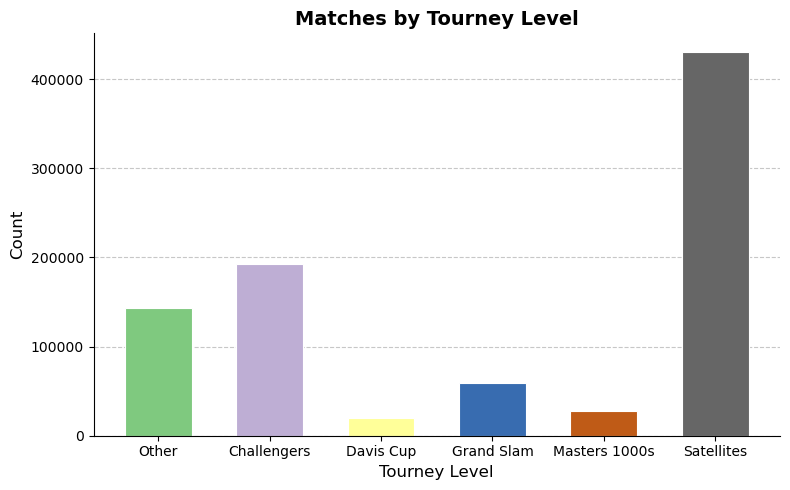

In [57]:
df_tourney_level = df.groupby('tourney_level').size().reset_index(name='count')
df_tourney_level = df_tourney_level[df_tourney_level['tourney_level'].isin(['S','C','A','G','M','D'])]

level_names = {
    'S': 'Satellites',
    'C': 'Challengers',
    'A': 'Other',
    'G': 'Grand Slam',
    'M': 'Masters 1000s',
    'D': 'Davis Cup'
}

df_tourney_level['tourney_level'] = df_tourney_level['tourney_level'].map(level_names)

fig, ax = plt.subplots(figsize=(8, 5))

cmap = cm.get_cmap('Accent', len(df_tourney_level))
colors = [cmap(i) for i in range(len(df_tourney_level))]

ax.bar(
    df_tourney_level['tourney_level'],
    df_tourney_level['count'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

ax.set_xlabel('Tourney Level', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Matches by Tourney Level', fontsize=14, fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()